# 04 Asymptotic Analysis

Reproduces the formal asymptotic consequence Adv_DDS <= 2^{-(a+b)lambda}; dataset-derived means are used only as context, not to estimate cryptographic exponents.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0,str(ROOT/"src"))
from dds_analysis import *
DATA=ROOT/"data"; OUT=ROOT/"outputs"; OUT.mkdir(exist_ok=True)
df=load_seqacs(DATA); validate_schema(df)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")


Loaded 520,000 rows and 37 columns


In [2]:
print("Dataset mean QKD leakage:",df.qkd_information_leakage.mean())
print("Dataset mean PQC advantage:",df.pqc_adversarial_advantage.mean())
lam=np.arange(1,257); a=b=1.0
asym=pd.DataFrame({"lambda":lam,"QKD":adv_qkd(lam,a),"PQC":adv_pqc(lam,b),"DDS_bound":adv_dds(lam,a,b)})
asym.to_csv(OUT/"asymptotic_formal_results.csv",index=False)

Dataset mean QKD leakage: 0.14446152376923077
Dataset mean PQC advantage: 0.31355925175


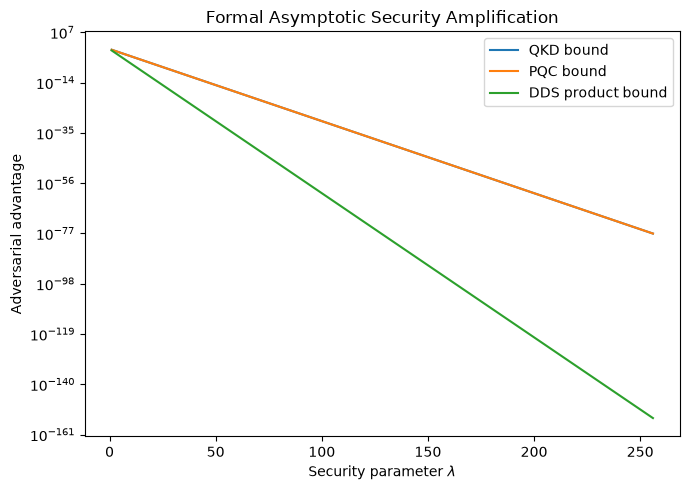

In [3]:
plt.figure(figsize=(7,5)); plt.semilogy(lam,asym.QKD,label="QKD bound"); plt.semilogy(lam,asym.PQC,label="PQC bound"); plt.semilogy(lam,asym.DDS_bound,label="DDS product bound")
plt.xlabel(r"Security parameter $\lambda$"); plt.ylabel("Adversarial advantage"); plt.title("Formal Asymptotic Security Amplification")
plt.legend(); plt.tight_layout(); plt.savefig(OUT/"fig_asymptotic_formal.png",dpi=300); plt.show()